In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()
DB_URL = os.getenv("DB_URL")
engine = create_engine(DB_URL)

pd.read_sql('SELECT 1 AS STATUS;', engine)

with engine.connect() as connected:
    
    print("Database connection status: 🟢 Connected")

Database connection status: 🟢 Connected


In [20]:
query = 'SELECT t.transaction_id, t.account_number, t.amount, t.transaction_type, t.date_time, a.spending_profile FROM transactions t JOIN accounts a ON t.account_number = a.account_number'
df = pd.read_sql(query, engine)
print(df.shape)
display(df.head())

(996, 6)


,transaction_id,account_number,amount,transaction_type,date_time,spending_profile
0,1,1,154.54,Deposit,2025-08-26 06:55:36.432915,Low
1,2,1,426.58,ATM Withdrawal,2025-11-18 10:17:08.882577,Low
2,3,1,248.92,ATM Withdrawal,2026-07-05 15:51:08.359488,Low
3,4,1,430.69,Deposit,2022-10-16 03:20:42.670979,Low
4,5,1,409.94,Deposit,2023-11-28 15:02:48.626300,Low


In [21]:
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 996 entries, 0 to 995
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    996 non-null    int64         
 1   account_number    996 non-null    int64         
 2   amount            996 non-null    float64       
 3   transaction_type  996 non-null    str           
 4   date_time         996 non-null    datetime64[us]
 5   spending_profile  996 non-null    str           
dtypes: datetime64[us](1), float64(1), int64(2), str(2)
memory usage: 46.8 KB


,transaction_id,account_number,amount,date_time
count,996.000000,996.000000,996.000000,996
mean,498.500000,27.840361,3222.625532,2025-06-18 10:21:21.974815
min,1.000000,1.000000,4.760000,2022-10-16 03:20:42.670979
25%,249.750000,16.000000,285.085000,2024-12-04 23:08:50.521638
50%,498.500000,31.000000,459.080000,2025-08-09 02:28:24.077139
75%,747.250000,40.000000,3177.577500,2026-03-11 08:35:39.627920
max,996.000000,50.000000,72000.000000,2026-09-12 01:11:12.341335
std,287.664735,14.826217,8040.242338,NaN


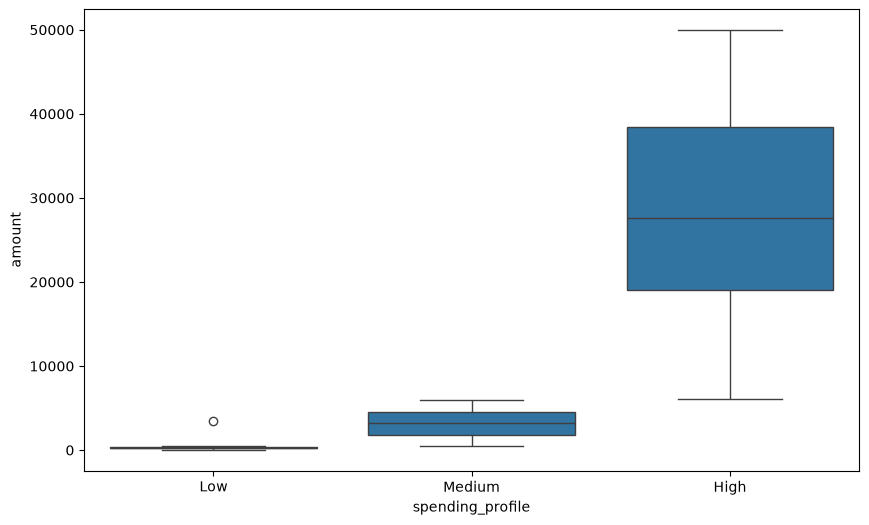

In [106]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x = 'spending_profile', y = 'amount')

plt.show()


In [107]:
anomalies = df[
    ((df['spending_profile'] == 'Low') & (df['amount'] > 500)) |
    ((df['spending_profile'] == 'Medium') & (df['amount'] > 6000)) |
    ((df['spending_profile'] == 'High') & (df['amount'] > 50000))
]
anomalies[['transaction_id', 'account_number', 'amount', 'spending_profile']]

,transaction_id,account_number,amount,spending_profile
174,175,11,3500.0,Low


In [108]:
df['time_diff_sec'] = (
    df.sort_values('date_time')
      .groupby('account_number')['date_time']
      .diff()
      .dt.total_seconds()
)
bursts = df[df['time_diff_sec'] < 120].sort_values(['account_number', 'date_time'])
bursts[['transaction_id', 'account_number', 'transaction_type', 'amount', 'date_time', 'time_diff_sec']]

,transaction_id,account_number,transaction_type,amount,date_time,time_diff_sec
930,931,47,Withdrawal,10.22,2024-12-30 04:41:36.208378,80.0
931,932,47,Withdrawal,4.77,2024-12-30 04:43:06.208378,90.0
932,933,47,Withdrawal,5.40,2024-12-30 04:43:41.208378,35.0
933,934,47,Withdrawal,24.40,2024-12-30 04:44:51.208378,70.0


In [109]:
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 1021 entries, 0 to 1020
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    1021 non-null   int64         
 1   account_number    1021 non-null   int64         
 2   amount            1021 non-null   float64       
 3   transaction_type  1021 non-null   str           
 4   date_time         1021 non-null   datetime64[us]
 5   spending_profile  1021 non-null   str           
 6   time_diff_sec     986 non-null    float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(2)
memory usage: 56.0 KB


,transaction_id,account_number,amount,date_time,time_diff_sec
count,1021.000000,1021.000000,1021.000000,1021,9.860000e+02
mean,511.000000,27.820764,4770.098932,2025-07-23 21:59:40.237596,2.381872e+06
min,1.000000,1.000000,4.770000,2023-03-03 22:15:35.959445,3.500000e+01
25%,256.000000,15.000000,317.530000,2025-01-08 13:04:58.040305,6.429504e+05
50%,511.000000,27.000000,997.200000,2025-09-13 00:42:32.229777,1.512746e+06
75%,766.000000,42.000000,4196.430000,2026-03-19 10:35:52.139065,3.116016e+06
max,1021.000000,50.000000,49969.410000,2026-09-13 17:23:14.804478,2.513962e+07
std,294.881615,14.602652,9581.633320,NaN,2.670681e+06
